In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore", message=".*No frequency information.*")
warnings.filterwarnings("ignore", message=".*Maximum Likelihood optimization failed to converge.*")

# Step 0: Load and prepare data

In [2]:
import os
os.chdir('D:\Fixed Income')
print(os.getcwd())

D:\Fixed Income


In [3]:
data = pd.read_csv('vn10y_govi_bond.csv')
rates = data['Close'].sort_index()

In [4]:
if not isinstance(rates.index, pd.DatetimeIndex):
    rates.index= pd.date_range(start='2016-03-09', periods=len(rates), freq='B')
    print("Index converted to DatetimeIndex assuming business days from 2016-03-09")

Index converted to DatetimeIndex assuming business days from 2016-03-09


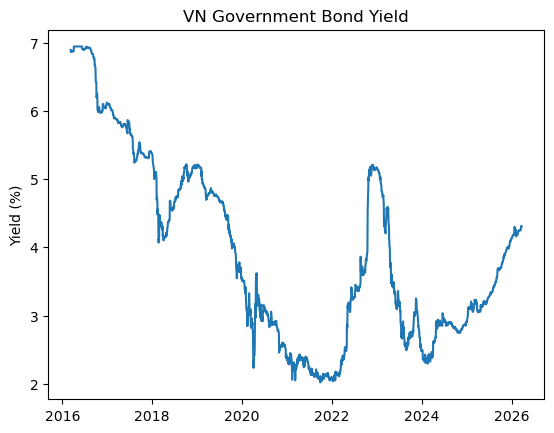

In [5]:
plt.plot(rates)
plt.title('VN Government Bond Yield')
plt.ylabel('Yield (%)')
plt.show()

# Step 1: Train/ Test split

In [6]:
train_size = int(len(rates) * 0.8)
train = rates[:train_size]
test = rates[train_size:]

In [7]:
print(f"Train period: {train.index[0]} → {train.index[-1]} ({len(train)} obs)")
print(f"Test  period: {test.index[0]}  → {test.index[-1]}  ({len(test)} obs)")

Train period: 2016-03-09 00:00:00 → 2024-03-20 00:00:00 (2096 obs)
Test  period: 2024-03-21 00:00:00  → 2026-03-24 00:00:00  (524 obs)


# Step 2: Stationarity check & Differencing

In [8]:
def check_stationarity(series, title=''):
    result = adfuller(series.dropna())
    print(f'{title} ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
    return result[1] < 0.05 # True = stationary

print("Original (train):")
is_stationary = check_stationarity(train, "Train_set")

Original (train):
Train_set ADF Statistic: -1.6102, p-value: 0.4779


In [9]:
# Differencing
d = 0
train_for_model = train.copy()
if not is_stationary:
    train_diff = train.diff().dropna()
    print("\nAfter 1st difference:")
    is_stationary = check_stationarity(train_diff, "Differenced train")
    d = 1
    train_for_model = train_diff


After 1st difference:
Differenced train ADF Statistic: -13.4418, p-value: 0.0000


<Figure size 1200x400 with 0 Axes>

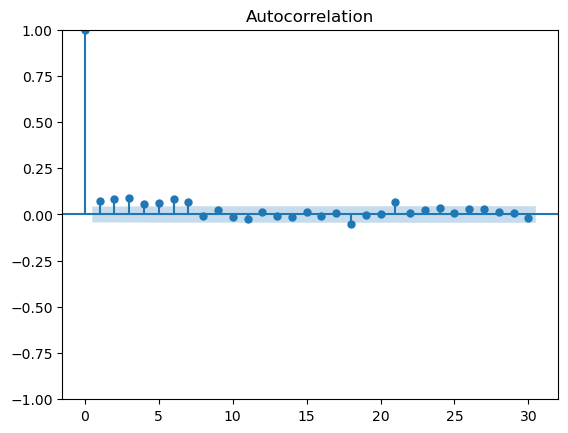

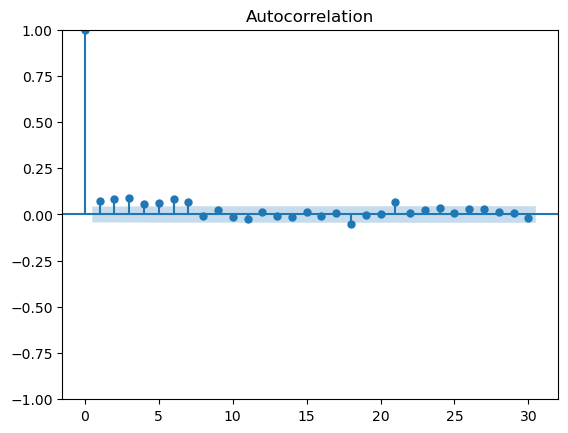

In [10]:
# ACF/ PACF on differenced train
plt.figure(figsize = (12,4))
plot_acf(train_for_model, lags=30)
plot_acf(train_for_model, lags=30)
plt.show()

# Step 3: Fit ARIMA model (manual fit)

In [11]:
p_range = range(0, 3)
q_range = range(0, 3)
orders_to_try = [(p, 1, q) for p in p_range for q in q_range
                 if not (p == 0 and q == 0)]
best_aic = np.inf
best_order = None
best_arima = None

In [12]:
for order in orders_to_try:
    try:
        model = ARIMA(train, order=order)
        fit = model.fit()
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = order
            best_arima = fit
        print(f"Order {order} → AIC: {fit.aic:.2f}")
    except:
        pass

Order (0, 1, 1) → AIC: -7178.71
Order (0, 1, 2) → AIC: -7187.83
Order (1, 1, 0) → AIC: -7180.32


C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order (1, 1, 1) → AIC: -7215.52
Order (1, 1, 2) → AIC: -7216.23
Order (2, 1, 0) → AIC: -7192.18


C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order (2, 1, 1) → AIC: -7216.04


C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order (2, 1, 2) → AIC: -7211.92


In [13]:
print(f"\nBest ARIMA{best_order} AIC: {best_aic:.2f}")
print(best_arima.summary())


Best ARIMA(1, 1, 2) AIC: -7216.23
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2096
Model:                 ARIMA(1, 1, 2)   Log Likelihood                3612.113
Date:                Thu, 12 Mar 2026   AIC                          -7216.226
Time:                        22:24:58   BIC                          -7193.637
Sample:                    03-09-2016   HQIC                         -7207.951
                         - 03-20-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8279      0.032     26.255      0.000       0.766       0.890
ma.L1         -0.7757      0.033    -23.745      0.000      -0.840      -0.712
ma.L2          0.

In [14]:
arima_residuals = best_arima.resid

# Step 4: Fit GARCH on ARIMA Residuals (Train)

In [15]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [16]:
from arch import arch_model

In [17]:
# GARCH(1,1) is standard and robust for financial volatility
garch_model = arch_model(arima_residuals, vol='Garch', p=1, q=1, mean='Zero', rescale=True)
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -866.010
Distribution:                  Normal   AIC:                           1738.02
Method:            Maximum Likelihood   BIC:                           1754.96
                                        No. Observations:                 2096
Date:                Thu, Mar 12 2026   Df Residuals:                     2096
Time:                        22:25:02   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0258  1.785e-02      1.446      0.148 

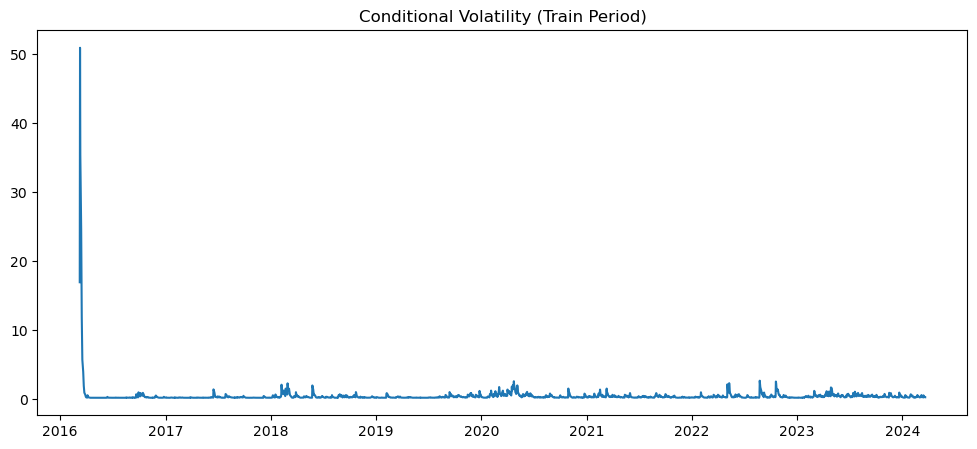

In [18]:
# Plot conditional volatility (train)
plt.figure(figsize=(12,5))
plt.plot(garch_fit.conditional_volatility)
plt.title('Conditional Volatility (Train Period)')
plt.show()

# Step 5: Time Series Forecasting

In [19]:
predictions = []
pred_intervals = []
vol_forecasts = []

arima_fit = ARIMA(train, order=best_order).fit()
history = train.copy()
resid_history = pd.Series(arima_fit.resid, index=train.index)

for t in range(len(test)):
    arima_fc = arima_fit.forecast(steps=1).iloc[0]
    predictions.append(arima_fc)
    #GARCH on residuals so far
    garch = arch_model(resid_history, p=1, q=1, vol='Garch', mean='Zero', rescale=True).fit(disp='off')
    garch_fc = garch.forecast(horizon=1, reindex=False)
    fc_vol = np.sqrt(garch_fc.variance.iloc[-1,0])
    vol_forecasts.append(fc_vol)

    upper = arima_fc + 1.96*fc_vol
    lower = arima_fc - 1.96*fc_vol
    pred_intervals.append((lower, upper))

    actual = test.iloc[t]
    history = pd.concat([history, pd.Series([actual], index=[test.index[t]])])

    arima_fit = ARIMA(history, order=best_order).fit()
    new_resid = actual - arima_fc
    resid_history = pd.concat([resid_history, pd.Series([new_resid], index=[test.index[t]])])
    
# Convert to Series for plotting
predictions = pd.Series(predictions, index=test.index, name='ARIMA-GARCH forecast')
vol_forecasts = pd.Series(vol_forecasts,   index=test.index, name='cond_vol')
lower_bound = pd.Series([x[0] for x in pred_intervals], index=test.index, name='lower_95')
upper_bound = pd.Series([x[1] for x in pred_intervals], index=test.index, name='upper_95')

# Step 6: Evaluate forecast

In [20]:
# Point forecast metrics
rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)
print(f"Test RMSE: {rmse:.4f} | MAE: {mae:.4f}")

Test RMSE: 0.0214 | MAE: 0.0132


In [21]:
len(predictions) == len(test)

True

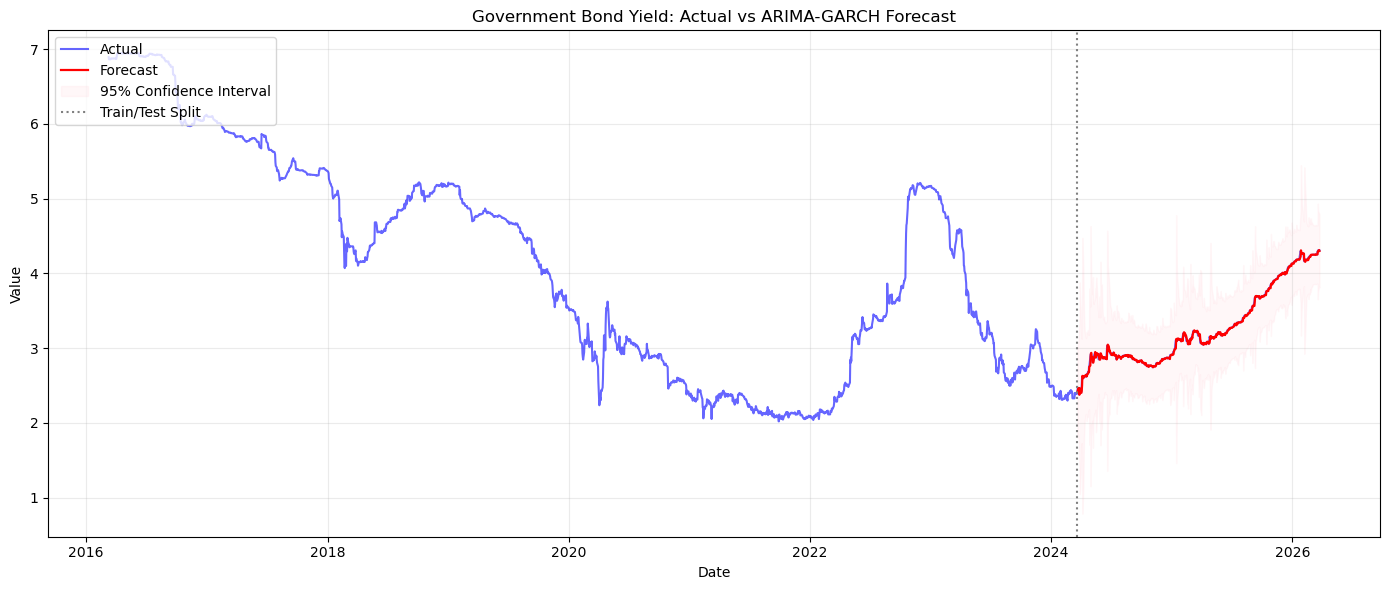

In [22]:
# Plot actual vs forecast
plt.figure(figsize=(14,6))
# Actual
plt.plot(rates, label = 'Actual', alpha = 0.6, color='blue')
# Forecast
plt.plot(predictions, color='red', linewidth=1.6, label='Forecast')
# Prediction interval
plt.fill_between(lower_bound.index,
                 lower_bound, upper_bound,
                 color='pink', alpha=0.12,
                 label = '95% Confidence Interval')
plt.axvline(x=test.index[0], color='gray', linestyle=':', label='Train/Test Split')
plt.title('Government Bond Yield: Actual vs ARIMA-GARCH Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Step 7: Future Forecast (beyond available data)

Next 1–4 weeks forecast:
            Forecast  Lower_CI  Upper_CI
2026-03-25  4.307830  3.856094  4.759566
2026-03-26  4.309593  3.784757  4.834430
2026-03-27  4.311058  3.722126  4.899990
2026-03-30  4.312275  3.665569  4.958981
2026-03-31  4.313285  3.613559  5.013012
2026-04-01  4.314125  3.565122  5.063127
2026-04-02  4.314822  3.519591  5.110053
2026-04-03  4.315401  3.476484  5.154317
2026-04-06  4.315881  3.435445  5.196318
2026-04-07  4.316281  3.396196  5.236366
2026-04-08  4.316613  3.358519  5.274706
2026-04-09  4.316888  3.322236  5.311540
2026-04-10  4.317117  3.287204  5.347029
2026-04-13  4.317307  3.253302  5.381312
2026-04-14  4.317465  3.220425  5.414504
2026-04-15  4.317596  3.188489  5.446703
2026-04-16  4.317705  3.157416  5.477994
2026-04-17  4.317795  3.127140  5.508450
2026-04-20  4.317870  3.097605  5.538135
2026-04-21  4.317933  3.068759  5.567106


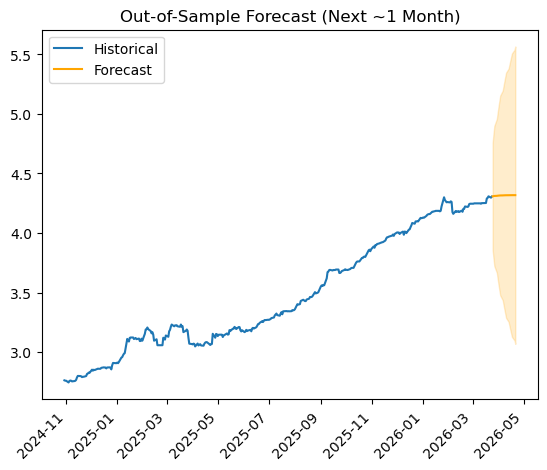

In [23]:
# Refit on full data
full_arima = ARIMA(rates, order=best_order).fit()
full_garch = arch_model(full_arima.resid, vol='Garch', p=1, q=1, mean='Zero', rescale = True).fit(disp='off')

# Forecast 20 steps (Next 1-4 weeks)
h = 20
arima_future = full_arima.forecast(steps=h)
garch_future = full_garch.forecast(horizon=h)

future_vol = np.sqrt(garch_future.variance.iloc[-1].values)
future_dates = pd.date_range(start = rates.index[-1] + pd.Timedelta(days=1),
                             periods=h, freq='B')

future_df = pd.DataFrame({
    'Forecast': arima_future,
    'Lower_CI': arima_future - 1.96 * future_vol,
    'Upper_CI': arima_future + 1.96 * future_vol
}, index=future_dates)

print("Next 1–4 weeks forecast:")
print(future_df)

# Plot
plt.plot(rates[-365:], label='Historical')
plt.plot(future_df['Forecast'], label='Forecast', color='orange')
plt.fill_between(future_df.index, future_df['Lower_CI'], future_df['Upper_CI'], color='orange', alpha=0.2)
plt.title('Out-of-Sample Forecast (Next ~1 Month)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()